# Población de vehículos eléctricos en Washington
## Análisis descriptivo de composición, concentración y calidad de datos


Vehículos eléctricos en Washington: composición del parque y concentración geográfica para la exploración de servicios.

### Resumen ejecutivo

Este reporte analiza la composición y distribución geográfica de los vehículos eléctricos registrados en el archivo para Washington, que incluye modelos hasta 2024. El objetivo es identificar zonas y segmentos que puedan orientar una investigación de oportunidades de servicios posventa, mantenimiento especializado y refacciones.

El análisis comprende vehículos totalmente eléctricos (BEV) e híbridos enchufables (PHEV). Tesla concentra más del 44% de los registros analizados y los BEV representan aproximadamente el 78% del conjunto. King encabeza la concentración por condado y Seattle destaca por ciudad. Estas participaciones describen los vehículos presentes en el archivo, no las ventas anuales ni el mercado automotriz total.

La concentración observada en Seattle justifica estudiar esta ubicación como candidata para servicios especializados. Sin embargo, los datos no permiten determinar la rentabilidad de una inversión, la demanda de mantenimiento ni la cantidad de cargadores que sería conveniente instalar. Para evaluar esas decisiones se requiere información adicional sobre competencia, costos, infraestructura existente y uso de los vehículos.

La fecha exacta de corte del archivo no está disponible; la presencia de modelos 2024 no implica que estén representadas todas las ventas de ese año.


## 1. Alcance y fuente

- Fuente original de referencia: [Washington DOL — Electric Vehicle Population Data](https://catalog.data.gov/dataset/electric-vehicle-population-data).
- Entrada usada: CSV proporcionado; se conserva una copia sin cambios en `data/`.
- La fecha exacta de corte no está disponible. Hay años-modelo hasta 2024, pero el archivo no es un historial de ventas y no permite determinar la cobertura completa de ese año.
- Universo analítico: filas con `State == "WA"`, después de comprobar duplicados.
- Unidad de análisis: un registro de vehículo; se verifica `DOL Vehicle ID` como identificador. El VIN disponible es parcial y no se usa para deduplicar.
- El archivo no incluye el universo de vehículos convencionales: las participaciones se calculan dentro de los EV analizados.
- No se incluyen todos los vehículos híbridos: únicamente los híbridos enchufables (PHEV).



In [1]:
from pathlib import Path
import hashlib
import json
import platform
import importlib.metadata as metadata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})
COLORS = {"BEV": "#176B87", "PHEV": "#D98E32"}
TYPE_MAP = {"Battery Electric Vehicle (BEV)": "BEV",
            "Plug-in Hybrid Electric Vehicle (PHEV)": "PHEV"}
# Puedes cambiar esta ruta si guardas el CSV en otra ubicación.
DATA_PATH = Path("data/electric_vehicle_population.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("electric_vehicle_population.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Coloca electric_vehicle_population.csv junto al notebook o dentro de data/.")
OUTPUT_DIR = Path("reports")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
SNAPSHOT_DATE = None  # Completar solo cuando se confirme la fecha de corte.

In [2]:
EXPECTED_SHA256 = "ad9ef46a63c0e68d46731dc1ad6dfafb313c0974e39e8eacc0ebdabb1a4a8469"
actual_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
if actual_sha256 != EXPECTED_SHA256:
    raise ValueError("El CSV no coincide con la copia revisada. Audita la nueva versión antes de actualizar su huella.")
# Leer como texto preserva códigos e identificadores y permite auditar conversiones.
raw = pd.read_csv(DATA_PATH, dtype="string")
required = {"State", "County", "City", "Postal Code", "Model Year", "Make", "Model",
            "Electric Vehicle Type", "Electric Range", "Base MSRP", "Legislative District",
            "DOL Vehicle ID", "2020 Census Tract", "Clean Alternative Fuel Vehicle (CAFV) Eligibility"}
assert required.issubset(raw.columns), f"Faltan columnas: {required - set(raw.columns)}"
manifest = {"file": DATA_PATH.name, "sha256": actual_sha256, "rows": len(raw),
            "columns": len(raw.columns), "snapshot_date": SNAPSHOT_DATE,
            "python": platform.python_version(),
            "packages": {p: metadata.version(p) for p in ["pandas", "numpy", "matplotlib"]}}
(OUTPUT_DIR / "execution_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
display(pd.DataFrame([{"Filas de entrada": len(raw), "Columnas": len(raw.columns)}]))
display(raw.head(3))

,Filas de entrada,Columnas
0,177866,17


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033007800
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,53061051938
2,5YJSA1E4XK,King,Seattle,WA,98109,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033006800


## 2. Auditoría y preparación

Los distritos, códigos postales y códigos censales son identificadores: no se imputan con medias o medianas. Se conservan faltantes cuando no impiden el análisis. Solo los gráficos geográficos necesitan una etiqueta territorial; se muestra `Sin dato` cuando falta.

Los ceros de autonomía se tratan como no disponibles para estadísticas técnicas, y los precios no positivos se excluyen del análisis de precios. Se conservan los campos originales y banderas de cobertura. Esta regla no elimina el vehículo de los conteos generales.

In [3]:
audit = pd.DataFrame({"faltantes": raw.isna().sum(), "tipo_original": raw.dtypes.astype(str)})
audit["faltantes_pct"] = audit["faltantes"] / len(raw) * 100
display(audit)
state_counts = raw["State"].fillna("Sin dato").value_counts().rename_axis("State").to_frame("registros")
display(state_counts)
exact_duplicates = int(raw.duplicated().sum())
# Quitar solo duplicados exactos; detenerse si un ID aparece con datos distintos.
unique_rows = raw.drop_duplicates().copy()
assert unique_rows["DOL Vehicle ID"].notna().all(), "Hay IDs ausentes: requiere revisión."
assert not unique_rows["DOL Vehicle ID"].duplicated().any(), "Hay IDs repetidos no idénticos: requiere revisión."
clean = unique_rows.copy()
for col in clean.columns:
    clean[col] = clean[col].str.strip().replace("", pd.NA)
clean["State"] = clean["State"].str.upper()
for col in ["Model Year", "Electric Range", "Base MSRP"]:
    parsed = pd.to_numeric(clean[col], errors="coerce")
    assert not (clean[col].notna() & parsed.isna()).any(), f"Conversión inválida: {col}"
    assert parsed.notna().all(), f"Valores ausentes en {col}: revisar antes de continuar."
    assert (parsed % 1 == 0).all(), f"Valores no enteros: {col}"
    clean[col] = parsed.astype("Int64")
assert clean["Model Year"].between(1900, pd.Timestamp.today().year + 2).all()
assert clean["Electric Range"].ge(0).all()
assert clean["Base MSRP"].ge(0).all()
# El alcance se define explícitamente; no confundir registros DOL con residencia WA.
wa = clean.loc[clean["State"].eq("WA")].copy()
assert len(wa) > 0
assert wa["Electric Vehicle Type"].isin(TYPE_MAP).all()
wa["ev_type"] = wa["Electric Vehicle Type"].map(TYPE_MAP)
wa["range_known"] = wa["Electric Range"].gt(0)
wa["price_known"] = wa["Base MSRP"].gt(0)
wa["range_miles"] = wa["Electric Range"].where(wa["range_known"])
wa["price_usd"] = wa["Base MSRP"].where(wa["price_known"])
# Códigos, no magnitudes numéricas. Preservar ceros iniciales.
wa["Postal Code"] = wa["Postal Code"].str.zfill(5)
wa["2020 Census Tract"] = wa["2020 Census Tract"].str.zfill(11)
assert wa["Postal Code"].dropna().str.fullmatch(r"\d{5}").all()
assert wa["2020 Census Tract"].dropna().str.fullmatch(r"\d{11}").all()
flow = pd.DataFrame({"etapa": ["Entrada", "Duplicados exactos retirados", "Fuera de WA o State ausente", "Universo WA"],
                     "registros": [len(raw), exact_duplicates, len(clean)-len(wa), len(wa)]})
assert len(raw) == exact_duplicates + (len(clean)-len(wa)) + len(wa)
display(flow)
display(wa.isna().sum().rename("faltantes_WA").to_frame())
flow.to_csv(TABLE_DIR / "row_audit.csv", index=False)
audit.to_csv(TABLE_DIR / "source_quality.csv")
N = len(wa)

,faltantes,tipo_original,faltantes_pct
VIN (1-10),0,string,0.000000
County,5,string,0.002811
City,5,string,0.002811
State,0,string,0.000000
Postal Code,5,string,0.002811
Model Year,0,string,0.000000
Make,0,string,0.000000
Model,0,string,0.000000
Electric Vehicle Type,0,string,0.000000
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0,string,0.000000


,registros
State,
WA,177477
CA,101
VA,46
MD,31
TX,23
NC,16
IL,15
CO,12
AZ,10


,etapa,registros
0,Entrada,177866
1,Duplicados exactos retirados,0
2,Fuera de WA o State ausente,389
3,Universo WA,177477


,faltantes_WA
VIN (1-10),0
County,0
City,0
State,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


### Decisiones de limpieza del dataset

**Delimitación del universo**

El análisis se restringió a los registros cuyo campo `State` corresponde a Washington (`WA`). Esto redujo el universo de 177,866 a 177,477 registros. Los 389 registros restantes se excluyeron por estar fuera del alcance geográfico definido, no por considerarse incorrectos.

**Tratamiento de valores faltantes**

Se conservaron los valores faltantes cuando no impedían realizar el análisis correspondiente. Por ejemplo, desconocer el distrito legislativo no impide contabilizar un vehículo por marca o tipo.

No se asignaron distritos mediante la mediana, porque sus números son identificadores geográficos, no cantidades. Imputarlos de esa forma introduciría una ubicación sin respaldo. Los códigos postales también se conservaron como texto y las categorías geográficas ausentes se muestran como “Sin dato” cuando corresponde.

**Diferencia entre faltantes y ceros**

Se distinguieron los campos vacíos de los valores registrados como cero. En autonomía eléctrica y precio base, los ceros se trataron como información no disponible para el análisis, en lugar de interpretarlos como vehículos sin autonomía o sin costo.

Estos registros se conservaron en los conteos generales de vehículos, pero se excluyeron de las estadísticas de autonomía o precio correspondientes. Se mantuvieron los valores originales y se calculó la cobertura disponible para hacer explícitas las limitaciones de cada análisis.

## 3. Composición y concentración

Los porcentajes de las siguientes tablas usan todos los registros WA como denominador. Los top 10 no suman necesariamente 100%.

,registros,porcentaje_WA
ev_type,,
BEV,138948,78.29
PHEV,38529,21.71


,registros,porcentaje_WA
Make,,
TESLA,79471,44.78
NISSAN,13984,7.88
CHEVROLET,13652,7.69
FORD,9177,5.17
BMW,7556,4.26
KIA,7423,4.18
TOYOTA,6255,3.52
VOLKSWAGEN,4993,2.81
JEEP,4469,2.52


,registros,porcentaje_WA
County,,
King,92740,52.25
Snohomish,21001,11.83
Pierce,13782,7.77
Clark,10409,5.86
Thurston,6428,3.62
Kitsap,5840,3.29
Spokane,4586,2.58
Whatcom,4253,2.4
Benton,2147,1.21


,registros,porcentaje_WA
King / Seattle,29447,16.59
King / Bellevue,8930,5.03
King / Redmond,6478,3.65
Clark / Vancouver,6193,3.49
King / Kirkland,5362,3.02
King / Sammamish,5280,2.98
King / Renton,4980,2.81
Snohomish / Bothell,4663,2.63
Thurston / Olympia,4299,2.42
Pierce / Tacoma,3722,2.1


,registros,porcentaje_WA
TESLA / MODEL Y,35921,20.24
TESLA / MODEL 3,30009,16.91
NISSAN / LEAF,13352,7.52
TESLA / MODEL S,7711,4.34
CHEVROLET / BOLT EV,6812,3.84
TESLA / MODEL X,5784,3.26
CHEVROLET / VOLT,4782,2.69
VOLKSWAGEN / ID.4,3928,2.21
JEEP / WRANGLER,3383,1.91
FORD / MUSTANG MACH-E,3316,1.87


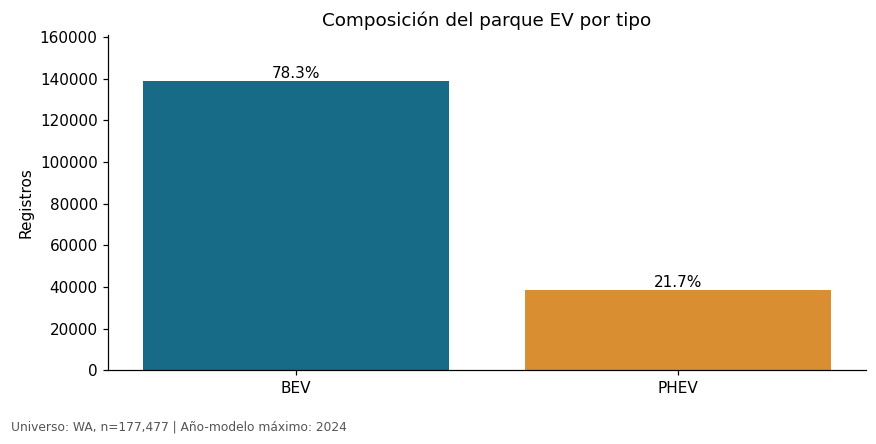

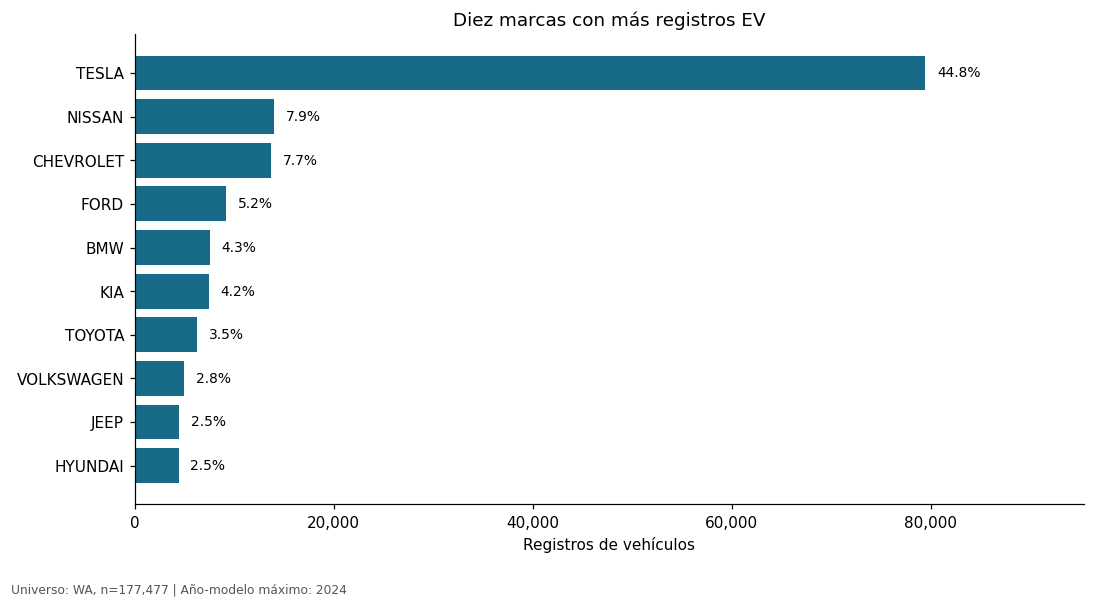

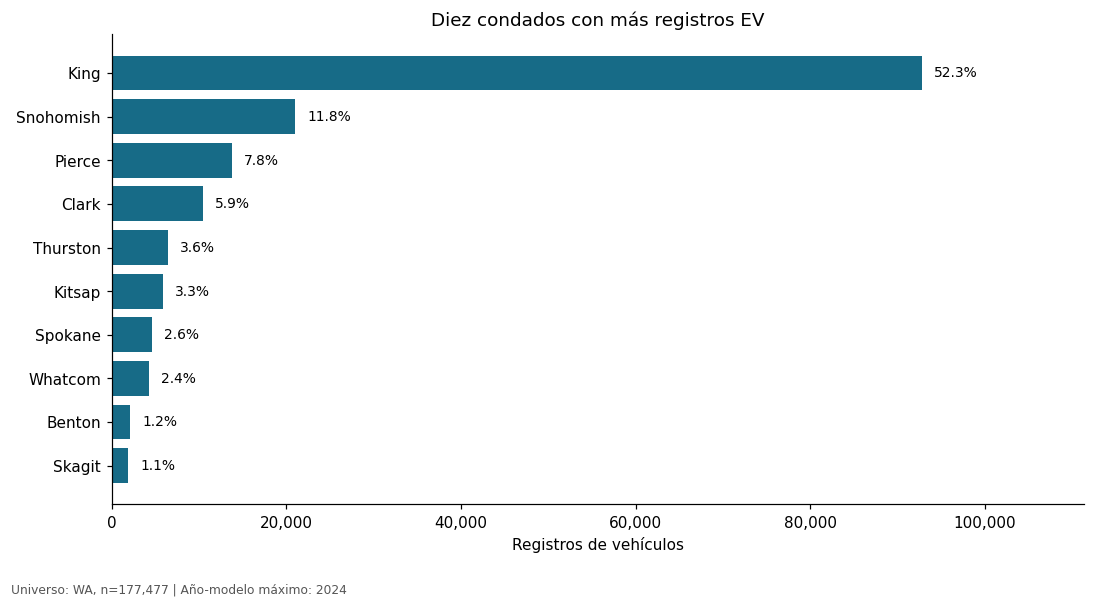

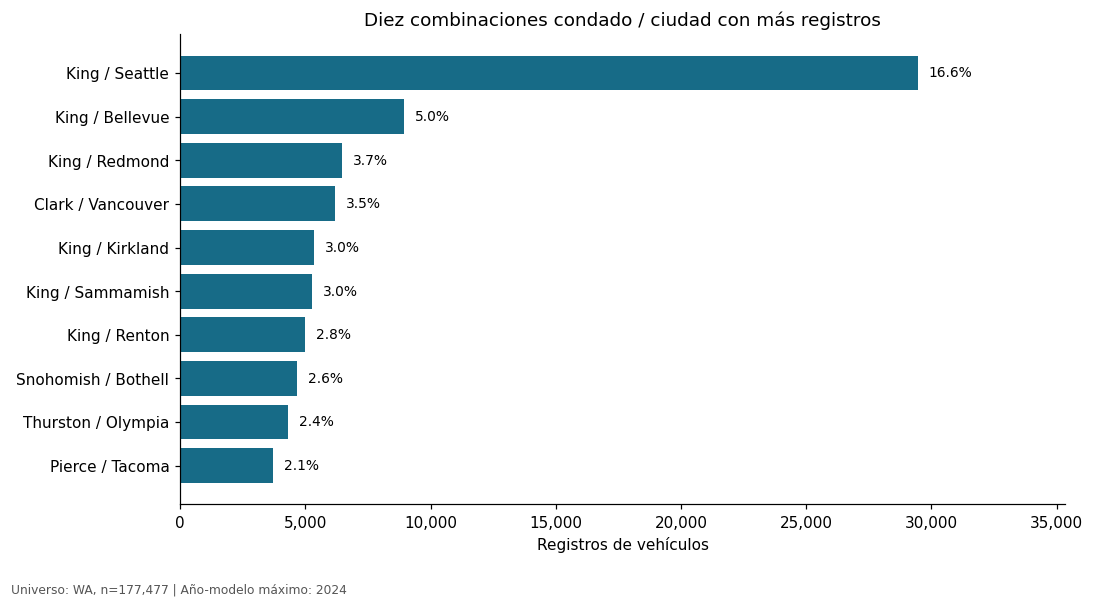

types
makes
counties
cities
models


In [4]:
def distribution(series):
    counts = series.fillna("Sin dato").value_counts()
    result = counts.rename("registros").to_frame()
    result["porcentaje_WA"] = counts / N * 100
    assert int(result["registros"].sum()) == N
    return result

def save_figure(fig, name):
    fig.text(0.01, 0.01,
    f"Universo: WA, n={N:,} | Año-modelo máximo: 2024",
    fontsize=8, color="#555555")
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def plot_ranking(table, title, name, limit=10):
    selected = table.head(limit).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.barh(selected.index.astype(str), selected["registros"], color="#176B87")
    for pos, (_, row) in enumerate(selected.iterrows()):
        ax.text(row["registros"] + selected["registros"].max()*.015, pos,
                f'{row["porcentaje_WA"]:.1f}%', va="center", fontsize=9)
    ax.set(xlabel="Registros de vehículos", title=title, xlim=(0, selected["registros"].max()*1.20))
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    save_figure(fig, name)

type_summary = distribution(wa["ev_type"])
make_summary = distribution(wa["Make"])
county_summary = distribution(wa["County"])
# Condado + ciudad evita fusionar nombres de ciudad repetidos en territorios distintos.
city_summary = distribution(wa["County"].fillna("Sin dato") + " / " + wa["City"].fillna("Sin dato"))
model_summary = distribution(wa["Make"].fillna("Sin dato") + " / " + wa["Model"].fillna("Sin dato"))
for name, table in {"types": type_summary, "makes": make_summary, "counties": county_summary,
                    "cities": city_summary, "models": model_summary}.items():
    table.to_csv(TABLE_DIR / f"{name}.csv")
    print(name)
    display(table.head(10).round(2))
fig, ax = plt.subplots(figsize=(8, 4))
for label in ["BEV", "PHEV"]:
    ax.bar(label, type_summary.loc[label, "registros"], color=COLORS[label])
    ax.text(label, type_summary.loc[label, "registros"], f'{type_summary.loc[label, "porcentaje_WA"]:.1f}%', ha="center", va="bottom")
ax.set(title="Composición del parque EV por tipo", ylabel="Registros", ylim=(0,type_summary["registros"].max()*1.16))
save_figure(fig, "01_ev_types")
plot_ranking(make_summary, "Diez marcas con más registros EV", "02_makes")
plot_ranking(county_summary, "Diez condados con más registros EV", "03_counties")
plot_ranking(city_summary, "Diez combinaciones condado / ciudad con más registros", "04_cities")

### Composición y geografía

Tesla concentra el 44.78% de los registros analizados. Sus modelos Model Y y Model 3 encabezan la distribución por modelo, con 35,921 y 30,009 registros, respectivamente. En la agrupación por condado y ciudad, King/Seattle presenta la mayor concentración, con 29,447 vehículos, equivalentes al 16.59% del conjunto.

El universo analizado está compuesto por un 78.29% de vehículos totalmente eléctricos (BEV) y un 21.71% de híbridos enchufables (PHEV). La presencia de Tesla contribuye a la participación de BEV dentro del conjunto. Un análisis cruzado por marca y tipo permitiría describir esa contribución y la composición del resto de las marcas.

Seattle concentra la mayor cantidad de registros entre las combinaciones condado–ciudad analizadas, pero esto no demuestra una mayor penetración eléctrica. Para comparar esa penetración entre ciudades sería necesario dividir los EV registrados en cada territorio entre el total de vehículos registrados allí, utilizando fechas y todas las categorías comparables.

## 4. Grupos por año-modelo

Se conservan todos los años-modelo disponibles, incluido 2024. No se calculan tasas de adopción anual ni proyecciones de ventas. Un grupo pequeño puede reflejar múltiples factores, incluyendo el momento del corte y la permanencia de vehículos en el registro. Los grupos pequeños también producen porcentajes extremos.

ev_type,BEV,PHEV,total,BEV_pct
Model Year,,,,
1997,1,0,1,100.00
1998,1,0,1,100.00
1999,5,0,5,100.00
2000,7,0,7,100.00
2002,2,0,2,100.00
2003,1,0,1,100.00
2008,19,0,19,100.00
2010,20,3,23,86.96
2011,699,76,775,90.19


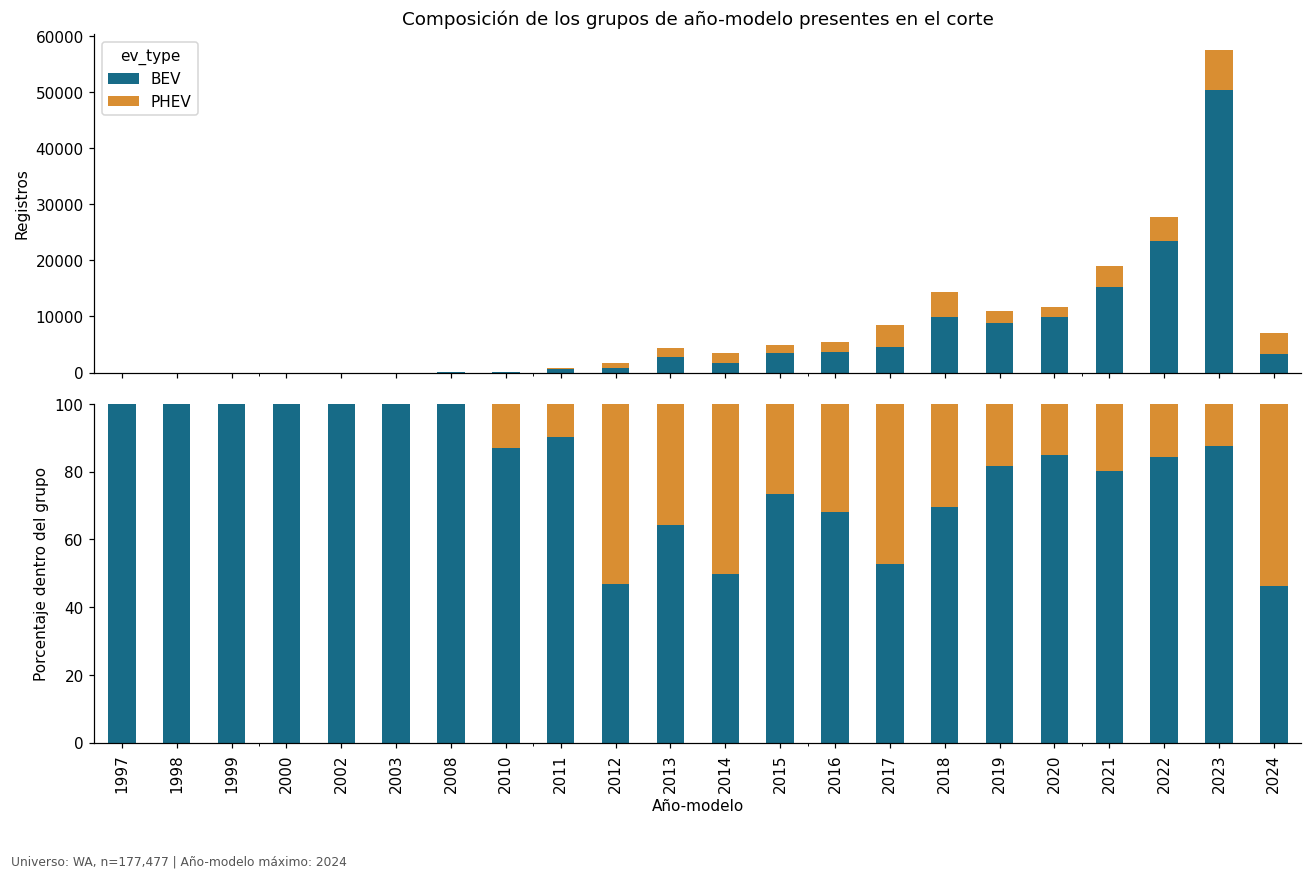

In [5]:
cohorts = pd.crosstab(wa["Model Year"], wa["ev_type"]).reindex(columns=["BEV", "PHEV"], fill_value=0).sort_index()
cohort_n = cohorts.sum(axis=1)
cohort_pct = cohorts.div(cohort_n, axis=0)*100
assert int(cohort_n.sum()) == N
assert np.allclose(cohort_pct.sum(axis=1), 100)
display(cohorts.assign(total=cohort_n, BEV_pct=cohort_pct["BEV"]).round(2))
cohorts.assign(total=cohort_n, BEV_pct=cohort_pct["BEV"]).to_csv(TABLE_DIR / "model_year_cohorts.csv")
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
cohorts.plot.bar(stacked=True, color=[COLORS[c] for c in cohorts.columns], ax=axes[0])
cohort_pct.plot.bar(stacked=True, color=[COLORS[c] for c in cohorts.columns], ax=axes[1], legend=False)
axes[0].set(title="Composición de los grupos de año-modelo presentes en el corte", ylabel="Registros", xlabel="")
axes[1].set(ylabel="Porcentaje dentro del grupo", xlabel="Año-modelo", ylim=(0,100))
save_figure(fig, "05_model_year_cohorts")

### Grupos por año-modelo

El año-modelo 2023 concentra la mayor cantidad de vehículos del archivo, con 57,520 registros. El grupo 2024 contiene 7,072 registros; sin embargo, la fecha de corte desconocida y la naturaleza del dataset impiden interpretar esta diferencia como una caída de ventas o estimar cuántos vehículos faltan para completar ese año.

La composición BEV/PHEV varía entre los grupos. La participación de PHEV disminuye del 19.87% en el año-modelo 2021 al 12.47% en 2023, mientras que en el grupo 2024 alcanza el 53.78%. Esta diferencia merece investigación adicional, pero no demuestra por sí sola un cambio sostenido en las preferencias del mercado.

Estos resultados describen los grupos por año-modelo presentes en el archivo; no representan ventas anuales ni tasas de crecimiento de adopción.

In [6]:
from sklearn.linear_model import LinearRegression

# Filtrar los datos de cohort_n para los años 2015 a 2023
data_for_regression = cohort_n.loc[2015:2023]

# Preparar los datos para la regresión lineal
X = data_for_regression.index.values.reshape(-1, 1)  # Años como característica
y = data_for_regression.values  # Total de vehículos como objetivo

# Crear y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X, y)

# Extrapolar el conteo del grupo año-modelo 2024; no ventas anuales
year_2024 = np.array([[2024]])
predicted_2024 = model.predict(year_2024)

print(f"Total de vehículos (2015-2023) usados para la regresión:\n{data_for_regression}")
print(f"Extrapolación exploratoria del conteo para el año-modelo 2024: {round(predicted_2024[0]):,}")

Total de vehículos (2015-2023) usados para la regresión:
Model Year
2015     4826
2016     5469
2017     8536
2018    14286
2019    10913
2020    11740
2021    19063
2022    27709
2023    57520
dtype: int64
Extrapolación exploratoria del conteo para el año-modelo 2024: 42,452


In [7]:
from sklearn.linear_model import LinearRegression

# Filtrar los datos de cohort_n para los años 2020 a 2023
data_for_regression = cohort_n.loc[2020:2023]

# Preparar los datos para la regresión lineal
X = data_for_regression.index.values.reshape(-1, 1)  # Años como característica
y = data_for_regression.values  # Total de vehículos como objetivo

# Crear y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X, y)

# Extrapolar el conteo del grupo año-modelo 2024; no ventas anuales
year_2024 = np.array([[2024]])
predicted_2024 = model.predict(year_2024)

print(f"Total de vehículos (2020-2023) usados para la regresión:\n{data_for_regression}")
print(f"Extrapolación exploratoria del conteo para el año-modelo 2024: {round(predicted_2024[0]):,}")

Total de vehículos (2020-2023) usados para la regresión:
Model Year
2020    11740
2021    19063
2022    27709
2023    57520
dtype: int64
Extrapolación exploratoria del conteo para el año-modelo 2024: 65,504


### Sensibilidad de la extrapolación al periodo utilizado

La regresión lineal produjo una extrapolación de aproximadamente **42,451 registros** para el año-modelo 2024 al utilizar los grupos 2015–2023. Al restringir el ajuste a 2020–2023, el resultado fue de **65,504 registros**.

La diferencia, equivalente a una reducción aproximada del 35.2% al ampliar el periodo, muestra que el resultado depende considerablemente de los años-modelo seleccionados. Ninguna de estas cifras se ha validado como una predicción de observaciones nuevas.

El ejercicio supone que la relación observada entre año-modelo y cantidad de registros puede extenderse al siguiente grupo. Los ajustes utilizan nueve observaciones agregadas para 2015–2023 y cuatro para 2020–2023; ambos son sensibles al elevado conteo de 2023. No se ha demostrado su capacidad predictiva mediante una evaluación independiente.

La cifra se presenta exclusivamente como una extrapolación exploratoria. No representa ventas durante 2024, registros al cierre de ese año ni una estimación de vehículos faltantes en el archivo. La fecha de corte desconocida y la naturaleza de los datos impiden esas interpretaciones.

## 5. Cobertura de autonomía y precios

Las autonomías positivas se resumen en millas y por tipo de vehículo. Excluir ceros no garantiza una muestra representativa: se muestra la cobertura por tipo y año-modelo. La categoría CAFV se usa como diagnóstico del registro, no como comprobación de acceso a incentivos vigentes.

,registros,autonomia_disponible,precio_disponible,autonomia_pct,precio_pct
ev_type,,,,,
BEV,138948,47157,2132,33.94,1.53
PHEV,38529,38529,1199,100.0,3.11


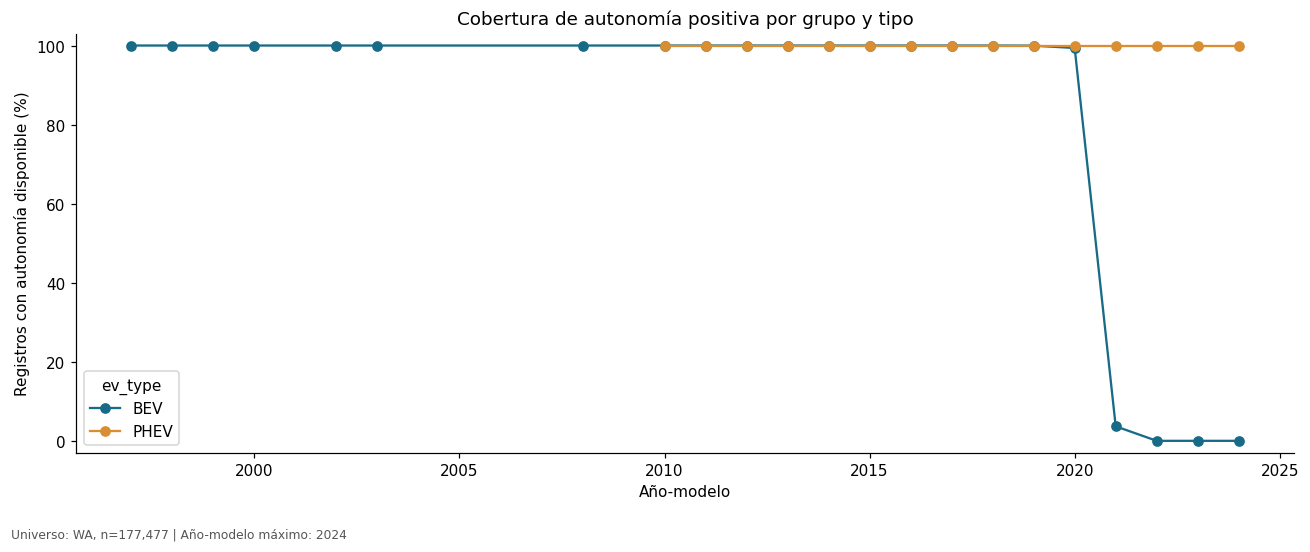

,count,median,min,max
ev_type,,,,
BEV,47157,215.0,29,337
PHEV,38529,28.0,6,153


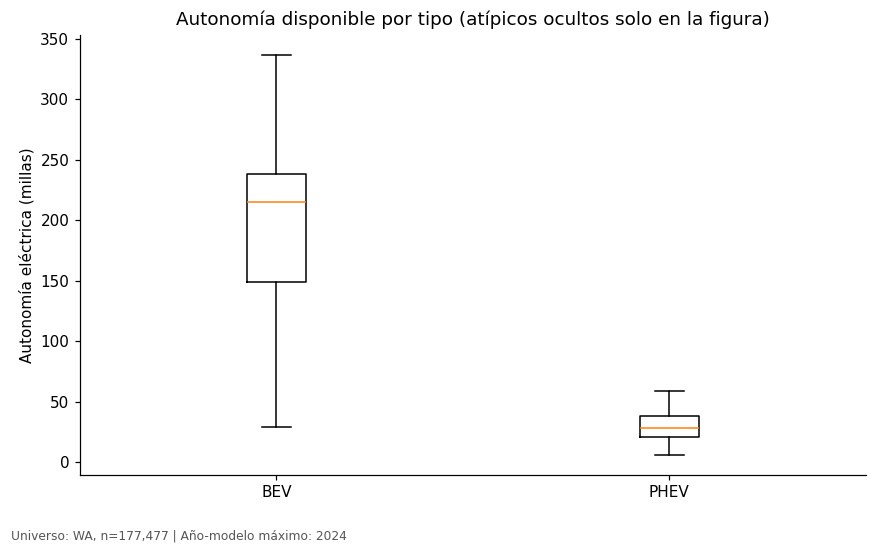

,autonomía no disponible,autonomía positiva
Clean Alternative Fuel Vehicle (CAFV) Eligibility,,
Clean Alternative Fuel Vehicle Eligible,0,66166
Eligibility unknown as battery range has not been researched,91791,0
Not eligible due to low battery range,0,19520


,MSRP_USD_solo_positivos
count,3331.0
mean,57041.230862
std,22793.009302
min,31950.0
25%,39995.0
50%,59900.0
75%,69900.0
max,845000.0


,muestra,n,r_año_autonomia
0,Todos WA: incluye ceros originales,177477,-0.477023
1,WA con autonomía positiva,85686,-0.059986


,range_miles,price_usd
range_miles,1.000000,0.406885
price_usd,0.406885,1.000000


Cobertura de precio positivo en WA: 1.88%
Registros con precio y autonomía positivos: 3,331 (1.88% de WA)


In [8]:
coverage = wa.groupby("ev_type").agg(registros=("DOL Vehicle ID", "size"),
    autonomia_disponible=("range_known", "sum"), precio_disponible=("price_known", "sum"))
coverage["autonomia_pct"] = coverage["autonomia_disponible"] / coverage["registros"] * 100
coverage["precio_pct"] = coverage["precio_disponible"] / coverage["registros"] * 100
display(coverage.round(2))
coverage.to_csv(TABLE_DIR / "coverage_by_type.csv")
coverage_year = wa.groupby(["Model Year", "ev_type"], observed=True).agg(
    registros=("DOL Vehicle ID", "size"), autonomia_pct=("range_known", "mean"), precio_pct=("price_known", "mean"))
coverage_year[["autonomia_pct", "precio_pct"]] *= 100
coverage_year.to_csv(TABLE_DIR / "coverage_by_cohort.csv")
fig, ax = plt.subplots(figsize=(12, 5))
coverage_year["autonomia_pct"].unstack().plot(ax=ax, marker="o", color=[COLORS[c] for c in coverage_year["autonomia_pct"].unstack().columns])
ax.set(title="Cobertura de autonomía positiva por grupo y tipo", ylabel="Registros con autonomía disponible (%)", xlabel="Año-modelo", ylim=(-3,103))
save_figure(fig, "06_range_coverage")
range_summary = wa.groupby("ev_type")["range_miles"].agg(["count", "median", "min", "max"])
display(range_summary)
range_summary.to_csv(TABLE_DIR / "range_summary.csv")
fig, ax = plt.subplots(figsize=(8, 5))
range_groups = [wa.loc[wa["ev_type"].eq(t), "range_miles"].dropna().astype(float).to_numpy() for t in ["BEV", "PHEV"]]
ax.boxplot(range_groups, tick_labels=["BEV", "PHEV"], showfliers=False)
ax.set(title="Autonomía disponible por tipo (atípicos ocultos solo en la figura)", ylabel="Autonomía eléctrica (millas)")
save_figure(fig, "07_range_by_type")
cafv_diagnostic = pd.crosstab(wa["Clean Alternative Fuel Vehicle (CAFV) Eligibility"].fillna("Sin dato"), wa["range_known"])
cafv_diagnostic.columns = ["autonomía positiva" if c else "autonomía no disponible" for c in cafv_diagnostic.columns]
display(cafv_diagnostic)
cafv_diagnostic.to_csv(TABLE_DIR / "cafv_range_diagnostic.csv")
price_coverage = wa["price_known"].mean()*100
print(f"Cobertura de precio positivo en WA: {price_coverage:.2f}%")
display(wa.loc[wa["price_known"], "price_usd"].describe().to_frame("MSRP_USD_solo_positivos"))
# Diagnóstico de correlación: se informa el tamaño de cada muestra.
# La comparación no es un experimento causal; los subconjuntos son diferentes.
correlation_checks = []
for label, subset in [("Todos WA: incluye ceros originales", wa),
                      ("WA con autonomía positiva", wa.loc[wa["range_known"]])]:
    corr = subset[["Model Year", "Electric Range"]].astype(float).corr().iloc[0,1]
    correlation_checks.append({"muestra": label, "n": len(subset), "r_año_autonomia": corr})
display(pd.DataFrame(correlation_checks))
# Precio-autonomía: no usar ceros de precio ni inferir representatividad del mercado.
paired = wa.loc[wa["range_known"] & wa["price_known"]]
print(f"Registros con precio y autonomía positivos: {len(paired):,} ({len(paired)/N*100:.2f}% de WA)")
if len(paired) > 2:
    display(paired[["range_miles", "price_usd"]].astype(float).corr())

### Calidad y límites de interpretación

En el universo analizado de Washington, el 48.28% de los registros tiene autonomía eléctrica positiva y únicamente el 1.88% dispone de precio base positivo. Los valores cero se trataron como información no disponible para estas estadísticas, conservando los vehículos en los conteos generales.

La cobertura de autonomía difiere considerablemente por tipo: alcanza el 100% entre los PHEV y el 33.94% entre los BEV. Al excluir autonomías cero, quedan especialmente poco representados los BEV modelo 2021 y desaparecen los correspondientes a los años-modelo 2022–2024. Por tanto, las estadísticas de autonomía describen el subconjunto con información disponible y no deben generalizarse a todos los vehículos del archivo.

La información de precios también presenta una cobertura desigual: ningún registro de los años-modelo 2021–2024 tiene precio positivo. En consecuencia, los precios observados no permiten afirmar que todo el parque eléctrico pertenece a segmentos de precio medio-alto. Además, el precio base registrado no equivale necesariamente al precio de venta efectivo.

Las correlaciones deben interpretarse dentro de estos límites. Un coeficiente cercano a cero indica una asociación lineal débil en el subconjunto utilizado, pero no descarta relaciones no lineales ni diferencias entre segmentos. Tampoco demuestra causalidad.

### Hallazgos e implicaciones operativas

Los resultados permiten seleccionar territorios para una investigación inicial de servicios relacionados con vehículos eléctricos. Las acciones propuestas son exploratorias y requieren información adicional antes de recomendar inversiones.

| Hallazgo calculado | Posible acción exploratoria | Evidencia adicional necesaria |
|---|---|---|
| King concentra la mayor cantidad de registros por condado dentro de Washington. | Analizar la distribución de vehículos y servicios existentes dentro del condado. | Ubicación de talleres y cargadores, cobertura territorial, accesibilidad y desplazamientos. |
| King/Seattle encabeza las combinaciones condado–ciudad, con 29,447 registros. | Estudiar la demanda potencial de mantenimiento especializado y servicios posventa. | Competencia, frecuencia de mantenimiento, garantías, costos operativos y disposición de los usuarios a contratar servicios. |
| King/Bellevue y King/Redmond ocupan el segundo y tercer lugar, con 8,930 y 6,478 registros, respectivamente. | Comparar ambas ciudades como posibles áreas de servicio y estudiar si comparten una zona de atención. | Tiempos de traslado, flujos de movilidad, ubicación de clientes y cobertura de proveedores actuales. |

Para evaluar infraestructura de carga, los conteos de vehículos deben complementarse con información sobre cargadores existentes, potencia, disponibilidad, utilización y acceso a carga doméstica. También se requieren datos de desplazamientos, capacidad eléctrica y costos de instalación y operación.

La concentración de vehículos justifica investigar estas zonas, pero no demuestra por sí sola un déficit de cargadores ni permite determinar cuántos instalar o si la inversión sería rentable.

### Limitaciones y próximos pasos

La fecha exacta de corte del archivo no está disponible. Aunque incluye vehículos con años-modelo hasta 2024, no permite determinar la cobertura completa de ese año ni interpretar los conteos como ventas anuales. El análisis es transversal: describe los registros presentes en una extracción, sin observar su evolución a lo largo del tiempo.

El universo analizado se limita a registros de Washington e incluye vehículos totalmente eléctricos (BEV) e híbridos enchufables (PHEV). No incluye vehículos híbridos no enchufables ni de combustión interna. Por ello, los resultados describen la composición del conjunto eléctrico y no permiten calcular su penetración dentro del parque automotriz total.

La cobertura de autonomía y precio es desigual entre tipos y años-modelo. Las estadísticas calculadas con valores disponibles no deben generalizarse automáticamente a todos los vehículos analizados.

Como siguiente paso, se propone complementar el análisis de las zonas prioritarias con información sobre servicios posventa existentes, necesidades de mantenimiento, uso de los vehículos y costos operativos. Esta ampliación permitiría evaluar con mayor fundamento oportunidades de servicios especializados.

Para comparar la penetración eléctrica entre territorios, sería necesario incorporar el total de vehículos registrados en cada uno, utilizando fechas y categorías comparables. La expansión a otros estados quedaría como una etapa posterior, si el objetivo de negocio requiere ampliar la cobertura geográfica.

## 6. Comprobaciones finales y exportación

Estas comprobaciones detectan pérdida de filas, denominadores inconsistentes y valores técnicos no válidos. No sustituyen la revisión de la procedencia ni la confirmación de la fecha de corte.

In [9]:
assert wa["State"].eq("WA").all()
assert wa["DOL Vehicle ID"].is_unique
assert int(type_summary["registros"].sum()) == N
assert int(county_summary["registros"].sum()) == N
assert int(city_summary["registros"].sum()) == N
assert wa["range_miles"].dropna().gt(0).all()
assert wa["price_usd"].dropna().gt(0).all()
checks = {"input_rows": len(raw), "wa_rows": N, "excluded_non_wa_or_missing_state": len(clean)-N,
          "exact_duplicates": exact_duplicates, "range_available_pct": float(wa["range_known"].mean()*100),
          "price_available_pct": float(price_coverage), "figures": len(list(FIGURE_DIR.glob("*.png"))),
          "status": "validaciones_completadas"}
(OUTPUT_DIR / "validation_summary.json").write_text(json.dumps(checks, indent=2), encoding="utf-8")
display(pd.Series(checks, name="resultado").to_frame())


,resultado
input_rows,177866
wa_rows,177477
excluded_non_wa_or_missing_state,389
exact_duplicates,0
range_available_pct,48.280059
price_available_pct,1.876863
figures,7
status,validaciones_completadas
